In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

rng = np.random.default_rng(7)
plt.rcParams["figure.figsize"] = (7, 4)
backend_sim = AerSimulator()

In [45]:
encoding_table = pd.DataFrame({
    "Bit": [0, 1, 0, 1],
    "Basis": ["Z (0)", "Z (0)", "X (1)", "X (1)"],
    "State": ["|0⟩", "|1⟩", "|+⟩", "|−⟩"],
    "Gates Applied": ["none", "X", "H", "X, H"]
})
encoding_table

,Bit,Basis,State,Gates Applied
0,0,Z (0),|0⟩,none
1,1,Z (0),|1⟩,X
2,0,X (1),|+⟩,H
3,1,X (1),|−⟩,"X, H"


In [46]:
def generate_random_bits_and_bases(n, seed=None):
    rng_local = np.random.default_rng(seed)
    bits = rng_local.integers(0, 2, n)
    bases = rng_local.integers(0, 2, n)
    return bits, bases

N = 30
abits, abase = generate_random_bits_and_bases(N, seed=1)

print("Alice's bits: ", abits)
print("Alice's bases:", abase, " (0=Z, 1=X)")

Alice's bits:  [0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 0 0]
Alice's bases: [0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 1 0 0 1]  (0=Z, 1=X)


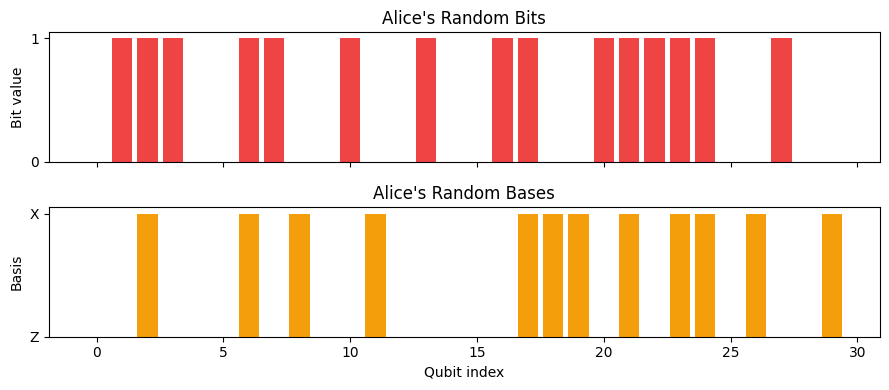

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

axes[0].bar(range(N), abits, color=['#3b82f6' if b == 0 else '#ef4444' for b in abits])
axes[0].set_ylabel("Bit value")
axes[0].set_yticks([0, 1])
axes[0].set_title("Alice's Random Bits")

axes[1].bar(range(N), abase, color=['#10b981' if b == 0 else '#f59e0b' for b in abase])
axes[1].set_ylabel("Basis")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Z", "X"])
axes[1].set_xlabel("Qubit index")
axes[1].set_title("Alice's Random Bases")

plt.tight_layout()
plt.show()

In [48]:
def prepare_alice_circuit(bits, bases):
    n = len(bits)
    qc = QuantumCircuit(n, n)
    for i in range(n):
        if bits[i] == 1:
            qc.x(i)          # encode bit value first
        if bases[i] == 1:
            qc.h(i)          # rotate into X basis if needed
    return qc

qc = prepare_alice_circuit(abits, abase)
qc.barrier()
print(f"Circuit prepared with {qc.num_qubits} qubits.")

Circuit prepared with 30 qubits.


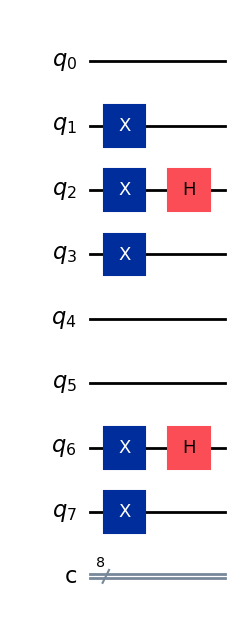

In [49]:
qc_small = prepare_alice_circuit(abits[:8], abase[:8])
qc_small.draw("mpl")

In [50]:
def ideal_channel(qc):
    """Placeholder: ideal channel, no modification to the circuit/state."""
    return qc

qc = ideal_channel(qc)

In [51]:
def add_bob_measurement(qc, bases):
    n = len(bases)
    for i in range(n):
        if bases[i] == 1:
            qc.h(i)
        qc.measure(i, i)
    return qc

bbase = rng.integers(0, 2, N)
qc = add_bob_measurement(qc, bbase)

print("Bob's bases:", bbase, " (0=Z, 1=X)")

Bob's bases: [1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 1]  (0=Z, 1=X)


In [52]:
job = backend_sim.run(qc, shots=1)
result = job.result()
counts = result.get_counts()

bitstring = list(counts.keys())[0]
bbits = np.array([int(b) for b in bitstring[::-1]])

print("Bob's measured bits:", bbits)

Bob's measured bits: [0 1 1 1 0 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0]


In [53]:
def sift_key(abits, abase, bbits, bbase):
    matches = abase == bbase
    alice_sifted = abits[matches]
    bob_sifted = bbits[matches]
    return alice_sifted, bob_sifted, matches

alice_sifted, bob_sifted, match_mask = sift_key(abits, abase, bbits, bbase)

comparison_df = pd.DataFrame({
    "Index": range(N),
    "Alice Basis": abase,
    "Bob Basis": bbase,
    "Bases Match": match_mask,
    "Alice Bit": abits,
    "Bob Bit": bbits,
})
comparison_df

,Index,Alice Basis,Bob Basis,Bases Match,Alice Bit,Bob Bit
0,0,0,1,False,0,0
1,1,0,1,False,1,1
2,2,1,1,True,1,1
3,3,0,1,False,1,1
4,4,0,1,False,0,0
5,5,0,1,False,0,0
6,6,1,1,True,1,1
7,7,0,0,True,1,1
8,8,1,0,False,0,1
9,9,0,0,True,0,0


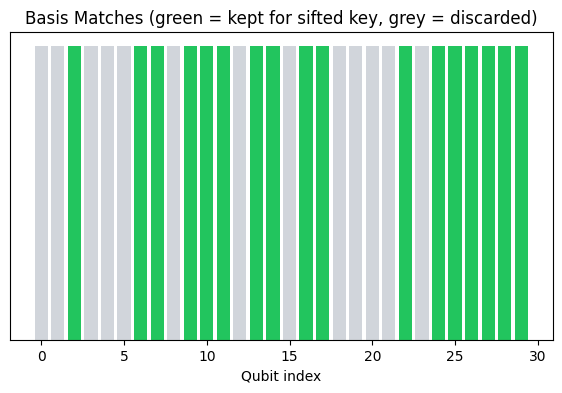

Sifted key (Alice): [1 1 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0]
Sifted key (Bob):   [1 1 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0]
Keys identical (expected, no Eve/noise): True


In [54]:
colors = ['#22c55e' if m else '#d1d5db' for m in match_mask]
plt.bar(range(N), np.ones(N), color=colors)
plt.yticks([])
plt.xlabel("Qubit index")
plt.title("Basis Matches (green = kept for sifted key, grey = discarded)")
plt.show()

print("Sifted key (Alice):", alice_sifted)
print("Sifted key (Bob):  ", bob_sifted)
print("Keys identical (expected, no Eve/noise):", np.array_equal(alice_sifted, bob_sifted))

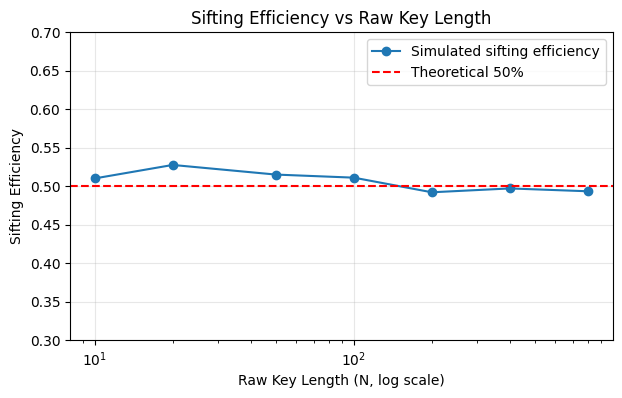

N=  10 -> avg sifting efficiency = 51.00%
N=  20 -> avg sifting efficiency = 52.75%
N=  50 -> avg sifting efficiency = 51.50%
N= 100 -> avg sifting efficiency = 51.10%
N= 200 -> avg sifting efficiency = 49.20%
N= 400 -> avg sifting efficiency = 49.70%
N= 800 -> avg sifting efficiency = 49.33%


In [55]:
def run_single_trial(n, seed=None):
    abits, abase = generate_random_bits_and_bases(n, seed=seed)
    qc = prepare_alice_circuit(abits, abase)
    qc = ideal_channel(qc)

    bbase_local = np.random.default_rng(seed + 999 if seed is not None else None).integers(0, 2, n)
    qc = add_bob_measurement(qc, bbase_local)

    job = backend_sim.run(qc, shots=1)
    counts = job.result().get_counts()
    bitstring = list(counts.keys())[0]
    bbits_local = np.array([int(b) for b in bitstring[::-1]])

    a_sift, b_sift, mask = sift_key(abits, abase, bbits_local, bbase_local)
    efficiency = np.sum(mask) / n
    return efficiency, len(a_sift), n

# %%
trial_sizes = [10, 20, 50, 100, 200, 400, 800]
avg_efficiencies = []
n_trials_per_size = 20

for size in trial_sizes:
    effs = [run_single_trial(size, seed=i)[0] for i in range(n_trials_per_size)]
    avg_efficiencies.append(np.mean(effs))

# %%
plt.plot(trial_sizes, avg_efficiencies, marker='o', label="Simulated sifting efficiency")
plt.axhline(0.5, color='red', linestyle='--', label="Theoretical 50%")
plt.xscale("log")
plt.xlabel("Raw Key Length (N, log scale)")
plt.ylabel("Sifting Efficiency")
plt.title("Sifting Efficiency vs Raw Key Length")
plt.ylim(0.3, 0.7)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for size, eff in zip(trial_sizes, avg_efficiencies):
    print(f"N={size:4d} -> avg sifting efficiency = {eff:.2%}")

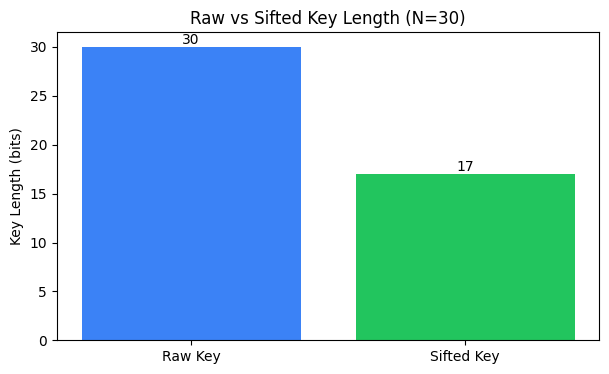

Raw key length: 30
Sifted key length: 17
This run's sifting efficiency: 56.67%


In [56]:
raw_len = N
sifted_len = len(alice_sifted)

plt.bar(["Raw Key", "Sifted Key"], [raw_len, sifted_len], color=["#3b82f6", "#22c55e"])
plt.ylabel("Key Length (bits)")
plt.title(f"Raw vs Sifted Key Length (N={N})")
for i, v in enumerate([raw_len, sifted_len]):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.show()

print(f"Raw key length: {raw_len}")
print(f"Sifted key length: {sifted_len}")
print(f"This run's sifting efficiency: {sifted_len/raw_len:.2%}")

In [57]:
def eve_measure_circuit(bits, bases, ebase):
    """Stage A: Alice prepares her states, Eve measures every qubit in
    her own random basis. Eve's results are only used later for qubits
    she chose to intercept."""
    n = len(bits)
    qc = prepare_alice_circuit(bits, bases)
    qc.barrier()
    for i in range(n):
        if ebase[i] == 1:
            qc.h(i)
        qc.measure(i, i)
    return qc


def run_bb84_with_eve(n, p_intercept, seed=None):
    """
    Full intercept-resend simulation using real Qiskit circuits.
    p_intercept: probability Eve intercepts any given qubit (attack strength).
    Returns: alice_sifted, bob_sifted, abits, abase, bbase, intercepted_mask
    """
    rng_local = np.random.default_rng(seed)
    abits, abase = generate_random_bits_and_bases(n, seed=rng_local.integers(1e9))

    # --- Stage A: Eve intercepts and measures ---
    ebase = rng_local.integers(0, 2, n)
    intercepted = rng_local.random(n) < p_intercept

    qcA = eve_measure_circuit(abits, abase, ebase)
    job = backend_sim.run(qcA, shots=1)
    bitstring = list(job.result().get_counts().keys())[0]
    ebits = np.array([int(b) for b in bitstring[::-1]])

    # --- Determine the state that actually reaches Bob ---
    incoming_bits = np.where(intercepted, ebits, abits)
    incoming_bases = np.where(intercepted, ebase, abase)

    # --- Stage B: Bob measures the incoming state ---
    bbase = rng_local.integers(0, 2, n)
    qcB = prepare_alice_circuit(incoming_bits, incoming_bases)
    qcB.barrier()
    qcB = add_bob_measurement(qcB, bbase)

    job = backend_sim.run(qcB, shots=1)
    bitstring = list(job.result().get_counts().keys())[0]
    bbits = np.array([int(b) for b in bitstring[::-1]])

    # --- Sift using Alice's ORIGINAL basis (Eve's basis is never revealed) ---
    alice_sifted, bob_sifted, mask = sift_key(abits, abase, bbits, bbase)

    return alice_sifted, bob_sifted, abits, abase, bbase, intercepted

# %% [markdown]
# ### Demonstration: full interception (p = 1.0) vs no interception (p = 0.0)

# %%
a_no_eve, b_no_eve, *_ = run_bb84_with_eve(200, p_intercept=0.0, seed=10)
a_full_eve, b_full_eve, *_ = run_bb84_with_eve(200, p_intercept=1.0, seed=10)

qber_no_eve = np.mean(a_no_eve != b_no_eve)
qber_full_eve = np.mean(a_full_eve != b_full_eve)

print(f"QBER with NO Eve (p=0.0):   {qber_no_eve:.2%}")
print(f"QBER with FULL Eve (p=1.0): {qber_full_eve:.2%}  (theory predicts ~25%)")

QBER with NO Eve (p=0.0):   0.00%
QBER with FULL Eve (p=1.0): 24.72%  (theory predicts ~25%)


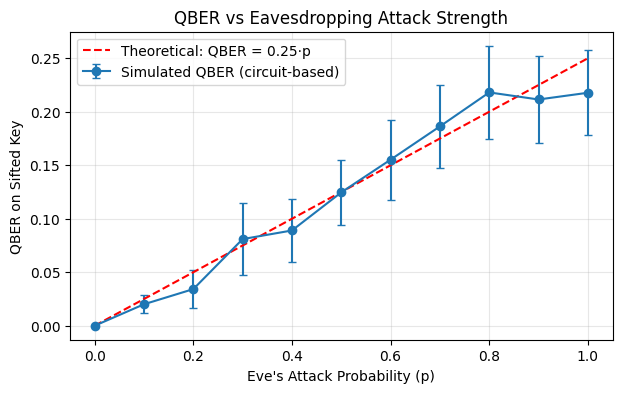

p=0.0 -> QBER = 0.00% (± 0.00%)
p=0.1 -> QBER = 2.01% (± 0.84%)
p=0.2 -> QBER = 3.42% (± 1.80%)
p=0.3 -> QBER = 8.10% (± 3.38%)
p=0.4 -> QBER = 8.90% (± 2.94%)
p=0.5 -> QBER = 12.47% (± 3.02%)
p=0.6 -> QBER = 15.52% (± 3.73%)
p=0.7 -> QBER = 18.63% (± 3.91%)
p=0.8 -> QBER = 21.81% (± 4.37%)
p=0.9 -> QBER = 21.15% (± 4.07%)
p=1.0 -> QBER = 21.78% (± 3.98%)


In [58]:
def qber_sweep(p_values, n_qubits=200, trials_per_point=15, seed=0):
    results = []
    for p in p_values:
        qbers = []
        for t in range(trials_per_point):
            a, b, *_ = run_bb84_with_eve(n_qubits, p, seed=seed + t + int(p * 1000))
            if len(a) > 0:
                qbers.append(np.mean(a != b))
        results.append((np.mean(qbers), np.std(qbers)))
    return np.array(results)

p_values = np.linspace(0, 1, 11)
qber_results = qber_sweep(p_values, n_qubits=200, trials_per_point=15)

# %%
plt.errorbar(p_values, qber_results[:, 0], yerr=qber_results[:, 1],
             marker='o', capsize=3, label="Simulated QBER (circuit-based)")
plt.plot(p_values, 0.25 * p_values, linestyle='--', color='red',
         label="Theoretical: QBER = 0.25·p")
plt.xlabel("Eve's Attack Probability (p)")
plt.ylabel("QBER on Sifted Key")
plt.title("QBER vs Eavesdropping Attack Strength")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for p, (mean_q, std_q) in zip(p_values, qber_results):
    print(f"p={p:.1f} -> QBER = {mean_q:.2%} (± {std_q:.2%})")

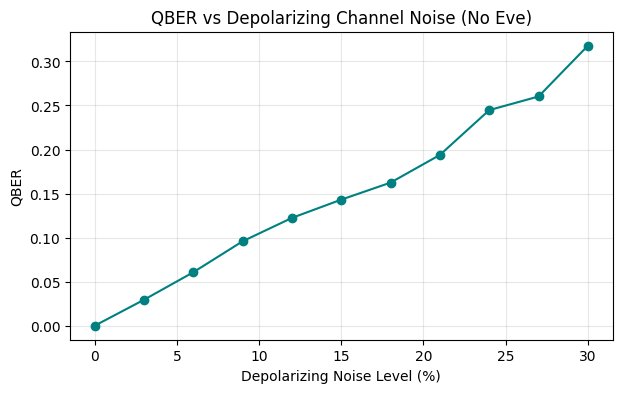

In [59]:
def apply_depolarizing_noise(bits, q, rng_local):
    flip_mask = rng_local.random(len(bits)) < q
    noisy_bits = bits.copy()
    noisy_bits[flip_mask] = 1 - noisy_bits[flip_mask]
    return noisy_bits


def run_bb84_with_noise(n, depolarizing_q=0.0, seed=None):
    """No Eve — pure channel noise only."""
    rng_local = np.random.default_rng(seed)
    a_sifted, b_sifted, *_ = run_bb84_with_eve(n, p_intercept=0.0, seed=seed)
    b_noisy = apply_depolarizing_noise(b_sifted, depolarizing_q, rng_local)
    return a_sifted, b_noisy

# %%
q_values = np.linspace(0, 0.3, 11)
depol_qber = []

for q in q_values:
    qbers = []
    for t in range(10):
        a, b = run_bb84_with_noise(200, depolarizing_q=q, seed=t + int(q * 1000))
        if len(a) > 0:
            qbers.append(np.mean(a != b))
    depol_qber.append(np.mean(qbers))

plt.plot(q_values * 100, depol_qber, marker='o', color='teal')
plt.xlabel("Depolarizing Noise Level (%)")
plt.ylabel("QBER")
plt.title("QBER vs Depolarizing Channel Noise (No Eve)")
plt.grid(alpha=0.3)
plt.show()

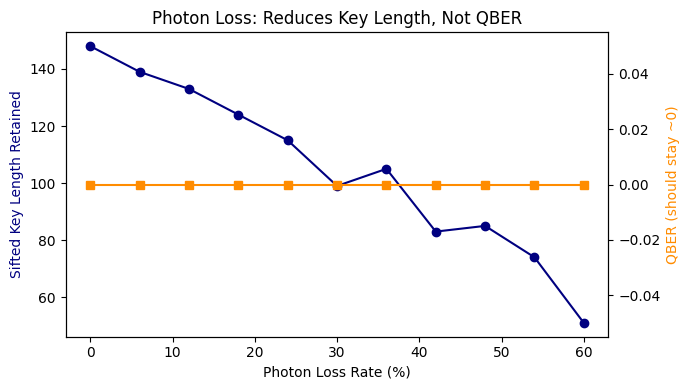

In [60]:
def apply_photon_loss(alice_sifted, bob_sifted, loss_rate, rng_local):
    keep_mask = rng_local.random(len(alice_sifted)) >= loss_rate
    return alice_sifted[keep_mask], bob_sifted[keep_mask]

# %%
loss_rates = np.linspace(0, 0.6, 11)
retained_lengths = []
loss_qber = []

for loss in loss_rates:
    rng_local = np.random.default_rng(int(loss * 1000))
    a, b, *_ = run_bb84_with_eve(300, p_intercept=0.0, seed=1)
    a_kept, b_kept = apply_photon_loss(a, b, loss, rng_local)
    retained_lengths.append(len(a_kept))
    loss_qber.append(np.mean(a_kept != b_kept) if len(a_kept) > 0 else 0)

fig, ax1 = plt.subplots()
ax1.plot(loss_rates * 100, retained_lengths, marker='o', color='navy', label="Sifted key length retained")
ax1.set_xlabel("Photon Loss Rate (%)")
ax1.set_ylabel("Sifted Key Length Retained", color='navy')

ax2 = ax1.twinx()
ax2.plot(loss_rates * 100, loss_qber, marker='s', color='darkorange', label="QBER")
ax2.set_ylabel("QBER (should stay ~0)", color='darkorange')

plt.title("Photon Loss: Reduces Key Length, Not QBER")
fig.tight_layout()
plt.show()

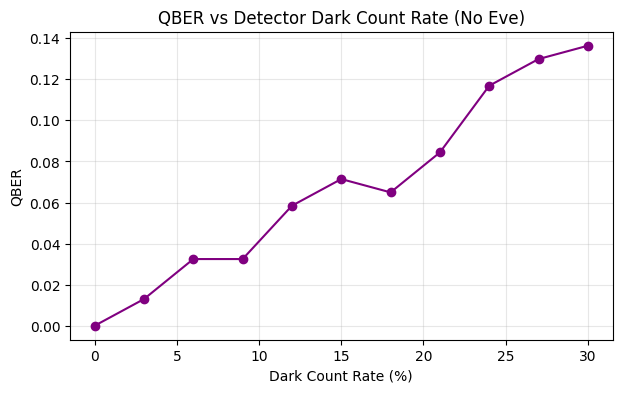

In [61]:
def apply_dark_counts(alice_sifted, bob_sifted, dark_rate, rng_local):
    bob_with_dark = bob_sifted.copy()
    dark_events = rng_local.random(len(bob_sifted)) < dark_rate
    bob_with_dark[dark_events] = rng_local.integers(0, 2, np.sum(dark_events))
    return alice_sifted, bob_with_dark

# %%
dark_rates = np.linspace(0, 0.3, 11)
dark_qber = []

for dr in dark_rates:
    rng_local = np.random.default_rng(int(dr * 1000))
    a, b, *_ = run_bb84_with_eve(300, p_intercept=0.0, seed=2)
    a2, b2 = apply_dark_counts(a, b, dr, rng_local)
    dark_qber.append(np.mean(a2 != b2))

plt.plot(dark_rates * 100, dark_qber, marker='o', color='purple')
plt.xlabel("Dark Count Rate (%)")
plt.ylabel("QBER")
plt.title("QBER vs Detector Dark Count Rate (No Eve)")
plt.grid(alpha=0.3)
plt.show()

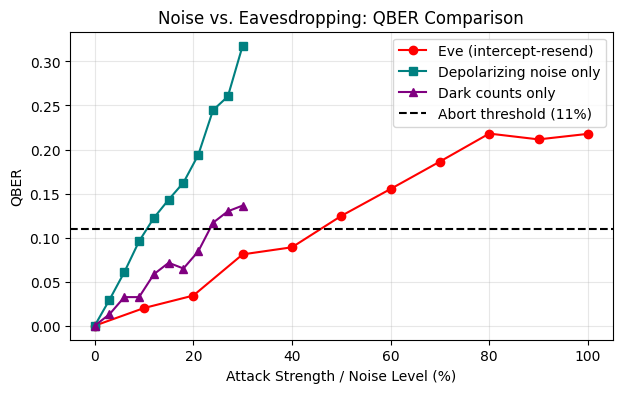

In [62]:
plt.plot(p_values * 100, qber_results[:, 0], marker='o', color='red', label="Eve (intercept-resend)")
plt.plot(q_values * 100, depol_qber, marker='s', color='teal', label="Depolarizing noise only")
plt.plot(dark_rates * 100, dark_qber, marker='^', color='purple', label="Dark counts only")
plt.axhline(0.11, color='black', linestyle='--', label="Abort threshold (11%)")

plt.xlabel("Attack Strength / Noise Level (%)")
plt.ylabel("QBER")
plt.title("Noise vs. Eavesdropping: QBER Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [63]:
ABORT_THRESHOLD = 0.11

detectable_p = p_values[qber_results[:, 0] >= ABORT_THRESHOLD]
min_detectable_p = detectable_p.min() if len(detectable_p) > 0 else None

print(f"Abort threshold: {ABORT_THRESHOLD:.0%}")
print(f"Minimum Eve attack probability reliably triggering abort: p ≈ {min_detectable_p:.2f}"
      if min_detectable_p else "No attack strength in sweep exceeded threshold")

threshold_table = pd.DataFrame({
    "Attack Strength p": p_values,
    "Simulated QBER": qber_results[:, 0],
    "Exceeds 11% Threshold?": qber_results[:, 0] >= ABORT_THRESHOLD,
    "Exceeds 25% Theoretical Max?": qber_results[:, 0] >= 0.25,
})
threshold_table

Abort threshold: 11%
Minimum Eve attack probability reliably triggering abort: p ≈ 0.50


,Attack Strength p,Simulated QBER,Exceeds 11% Threshold?,Exceeds 25% Theoretical Max?
0,0.0,0.000000,False,False
1,0.1,0.020071,False,False
2,0.2,0.034222,False,False
3,0.3,0.080975,False,False
4,0.4,0.089028,False,False
5,0.5,0.124650,True,False
6,0.6,0.155220,True,False
7,0.7,0.186316,True,False
8,0.8,0.218075,True,False
9,0.9,0.211472,True,False


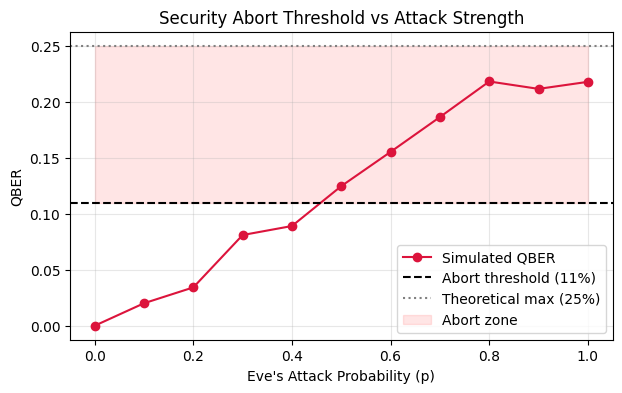

In [64]:
plt.plot(p_values, qber_results[:, 0], marker='o', color='crimson', label="Simulated QBER")
plt.axhline(ABORT_THRESHOLD, color='black', linestyle='--', label="Abort threshold (11%)")
plt.axhline(0.25, color='gray', linestyle=':', label="Theoretical max (25%)")
plt.fill_between(p_values, ABORT_THRESHOLD, 0.25, color='red', alpha=0.1, label="Abort zone")
plt.xlabel("Eve's Attack Probability (p)")
plt.ylabel("QBER")
plt.title("Security Abort Threshold vs Attack Strength")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [65]:
DEMO_P_INTERCEPT = 0.3   # produces QBER well below 11% on its own via partial interception... 
# NOTE: at p=0.3 pure Eve QBER ≈ 0.25*0.3 = 7.5%, used here just to generate realistic errors
alice_sifted_rec, bob_sifted_rec, *_ = run_bb84_with_eve(600, p_intercept=DEMO_P_INTERCEPT, seed=55)

actual_qber = np.mean(alice_sifted_rec != bob_sifted_rec)
print(f"Sifted key length: {len(alice_sifted_rec)}")
print(f"Observed QBER before reconciliation: {actual_qber:.2%}")
print(f"Mismatches to correct: {np.sum(alice_sifted_rec != bob_sifted_rec)}")

Sifted key length: 306
Observed QBER before reconciliation: 7.19%
Mismatches to correct: 22


In [66]:
def block_parity(bits):
    return int(np.sum(bits) % 2)


def binary_search_correct(alice_bits, bob_bits, indices, leak_counter):
    """Binary search a sub-block known to contain an odd number of errors,
    find and correct exactly one error in Bob's key. Each parity comparison
    made publicly costs 1 leaked bit."""
    if len(indices) == 1:
        idx = indices[0]
        bob_bits[idx] = alice_bits[idx]
        return leak_counter

    mid = len(indices) // 2
    left_idx = indices[:mid]
    right_idx = indices[mid:]

    a_parity_left = block_parity(alice_bits[left_idx])
    b_parity_left = block_parity(bob_bits[left_idx])
    leak_counter += 1

    if a_parity_left != b_parity_left:
        leak_counter = binary_search_correct(alice_bits, bob_bits, left_idx, leak_counter)
    else:
        leak_counter = binary_search_correct(alice_bits, bob_bits, right_idx, leak_counter)

    return leak_counter


def cascade_pass(alice_bits, bob_bits, block_size, rng_local):
    """Run one Cascade pass: shuffle key order, split into blocks, compare
    parities, correct any block with a parity mismatch."""
    n = len(alice_bits)
    perm = rng_local.permutation(n)
    inv_perm = np.argsort(perm)

    a_shuffled = alice_bits[perm]
    b_shuffled = bob_bits[perm].copy()

    leak = 0
    errors_found = 0
    n_blocks = int(np.ceil(n / block_size))

    for b in range(n_blocks):
        start, end = b * block_size, min((b + 1) * block_size, n)
        idx = np.arange(start, end)

        a_par = block_parity(a_shuffled[idx])
        b_par = block_parity(b_shuffled[idx])
        leak += 1

        if a_par != b_par:
            leak = binary_search_correct(a_shuffled, b_shuffled, idx, leak)
            errors_found += 1

    bob_corrected = b_shuffled[inv_perm]
    return bob_corrected, leak, errors_found


def run_cascade(alice_bits, bob_bits, max_passes=12, initial_block_size=8, seed=0):
    """
    Adaptive Cascade: keeps running additional passes (doubling block size
    and reshuffling each time) until either all mismatches are corrected
    or max_passes is reached. Returns a success flag so downstream stages
    know whether reconciliation actually completed.
    """
    rng_local = np.random.default_rng(seed)
    bob_current = bob_bits.copy()
    total_leak = 0
    history = []

    block_size = initial_block_size
    for p in range(1, max_passes + 1):
        bob_current, leak_p, errors_found = cascade_pass(alice_bits, bob_current, block_size, rng_local)
        total_leak += leak_p
        mismatches_remaining = int(np.sum(alice_bits != bob_current))
        history.append((p, mismatches_remaining, leak_p, total_leak))

        if mismatches_remaining == 0:
            break  # done early, no need to keep leaking more bits

        block_size = min(block_size * 2, max(len(alice_bits) // 2, 4))

    success = (int(np.sum(alice_bits != bob_current)) == 0)
    return bob_current, total_leak, history, success

# %%
bob_reconciled, total_leaked_bits, cascade_history, reconciliation_success = run_cascade(
    alice_sifted_rec, bob_sifted_rec, max_passes=12, initial_block_size=8, seed=7
)
print(f"Reconciliation success: {reconciliation_success}")

Reconciliation success: True


In [67]:
# %%
ABORT_THRESHOLD = 0.11

def attempt_reconciliation(alice_bits, bob_bits, abort_threshold=ABORT_THRESHOLD, **kwargs):
    qber = np.mean(alice_bits != bob_bits) if len(alice_bits) > 0 else 1.0
    if qber > abort_threshold:
        print(f"ABORT: QBER {qber:.2%} exceeds threshold {abort_threshold:.0%}. Discarding key.")
        return None, 0, [], False
    return run_cascade(alice_bits, bob_bits, **kwargs)

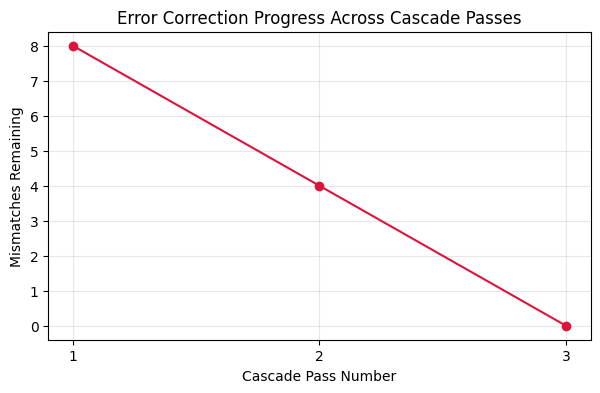

In [68]:
passes = [h[0] for h in cascade_history]
mismatches = [h[1] for h in cascade_history]

plt.plot(passes, mismatches, marker='o', color='crimson')
plt.xlabel("Cascade Pass Number")
plt.ylabel("Mismatches Remaining")
plt.title("Error Correction Progress Across Cascade Passes")
plt.grid(alpha=0.3)
plt.xticks(passes)
plt.show()

Total parity bits leaked during reconciliation: 147
As a fraction of sifted key length: 48.04%


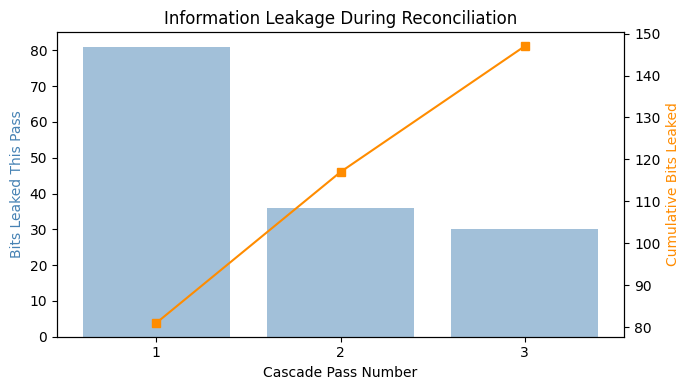

In [69]:
print(f"Total parity bits leaked during reconciliation: {total_leaked_bits}")
print(f"As a fraction of sifted key length: {total_leaked_bits / len(alice_sifted_rec):.2%}")

# ### Visualization — Leaked bits per pass vs cumulative leakage

# %%
leak_per_pass = [h[2] for h in cascade_history]
cumulative_leak = [h[3] for h in cascade_history]

fig, ax1 = plt.subplots()
ax1.bar(passes, leak_per_pass, alpha=0.5, color='steelblue', label="Leak per pass")
ax1.set_xlabel("Cascade Pass Number")
ax1.set_ylabel("Bits Leaked This Pass", color='steelblue')
ax1.set_xticks(passes)

ax2 = ax1.twinx()
ax2.plot(passes, cumulative_leak, color='darkorange', marker='s', label="Cumulative leak")
ax2.set_ylabel("Cumulative Bits Leaked", color='darkorange')

plt.title("Information Leakage During Reconciliation")
fig.tight_layout()
plt.show()

In [70]:
p_sweep_values = np.linspace(0.0, 0.6, 10)
trials_per_p = 10

leak_vs_p = []
qber_vs_p = []
success_vs_p = []
length_vs_p = []
abort_rate_vs_p = []

for p in p_sweep_values:
    leaks_this_p = []         # only from trials that actually attempted reconciliation
    qbers_this_p = []
    successes_this_p = []
    lengths_this_p = []
    aborts_this_p = []

    for t in range(trials_per_p):
        a_k, b_k, *_ = run_bb84_with_eve(400, p_intercept=p, seed=int(p * 10000) + t)
        if len(a_k) == 0:
            continue
        q = np.mean(a_k != b_k)

        b_rec, leak, _, success = attempt_reconciliation(
            a_k, b_k, max_passes=12, initial_block_size=8, seed=99 + t
        )

        aborted = (b_rec is None)
        aborts_this_p.append(aborted)
        qbers_this_p.append(q)
        successes_this_p.append(success)
        lengths_this_p.append(len(a_k))

        if not aborted:
            leaks_this_p.append(leak)   # exclude leak=0 placeholder from aborted trials

    qber_vs_p.append(np.mean(qbers_this_p))
    leak_vs_p.append(np.mean(leaks_this_p) if len(leaks_this_p) > 0 else np.nan)
    success_vs_p.append(np.mean(successes_this_p))
    length_vs_p.append(np.mean(lengths_this_p))
    abort_rate_vs_p.append(np.mean(aborts_this_p))

sort_idx = np.argsort(qber_vs_p)
qber_vs_p_sorted = np.array(qber_vs_p)[sort_idx]
leak_vs_p_sorted = np.array(leak_vs_p)[sort_idx]
length_vs_p_sorted = np.array(length_vs_p)[sort_idx]
abort_rate_vs_p_sorted = np.array(abort_rate_vs_p)[sort_idx]

print("Abort rate at each attack strength:")
for p, ar in zip(p_sweep_values, abort_rate_vs_p):
    print(f"  p={p:.2f} -> abort rate = {ar:.0%}")

ABORT: QBER 11.96% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.34% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.27% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.65% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.32% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.27% exceeds threshold 11%. Discarding key.
ABORT: QBER 15.18% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.09% exceeds threshold 11%. Discarding key.
ABORT: QBER 12.43% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.79% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.46% exceeds threshold 11%. Discarding key.
ABORT: QBER 15.23% exceeds threshold 11%. Discarding key.
ABORT: QBER 16.91% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.59% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.94% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.93% exceeds threshold 11%. Discarding key.
ABORT: QBER 15.82% exceeds threshold 11%. Discarding key.
ABORT: QBER 12

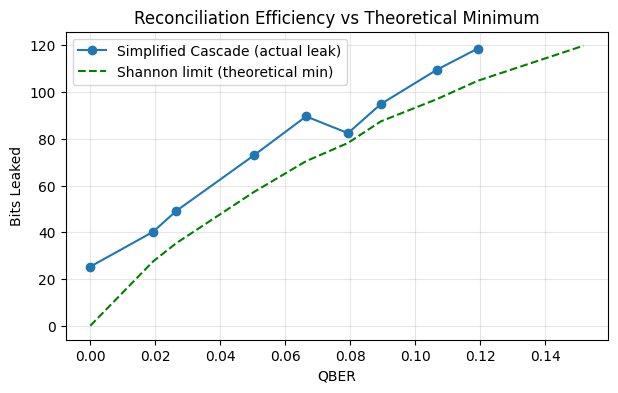

Reconciliation efficiency (actual/theoretical, closer to 1.0 = better):
  QBER=0.00% -> efficiency factor = N/A (QBER≈0, no real errors to correct)
  QBER=1.93% -> efficiency factor = 1.46x  (abort rate at this point: 0%)
  QBER=2.64% -> efficiency factor = 1.39x  (abort rate at this point: 0%)
  QBER=5.03% -> efficiency factor = 1.27x  (abort rate at this point: 0%)
  QBER=6.64% -> efficiency factor = 1.27x  (abort rate at this point: 0%)
  QBER=7.93% -> efficiency factor = 1.05x  (abort rate at this point: 30%)
  QBER=8.94% -> efficiency factor = 1.08x  (abort rate at this point: 30%)
  QBER=10.68% -> efficiency factor = 1.13x  (abort rate at this point: 40%)
  QBER=11.92% -> efficiency factor = 1.13x  (abort rate at this point: 50%)
  QBER=15.18% -> efficiency factor = N/A (all trials aborted, abort rate=100%)


In [71]:
# %%
def binary_entropy(q):
    q = np.clip(q, 1e-12, 1 - 1e-12)
    return -q * np.log2(q) - (1 - q) * np.log2(1 - q)

shannon_limit_sorted = length_vs_p_sorted * binary_entropy(qber_vs_p_sorted)

plt.plot(qber_vs_p_sorted, leak_vs_p_sorted, marker='o', label="Simplified Cascade (actual leak)")
plt.plot(qber_vs_p_sorted, shannon_limit_sorted, linestyle='--', color='green', label="Shannon limit (theoretical min)")
plt.xlabel("QBER")
plt.ylabel("Bits Leaked")
plt.title("Reconciliation Efficiency vs Theoretical Minimum")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

shannon_limit_sorted = length_vs_p_sorted * binary_entropy(qber_vs_p_sorted)
efficiency = leak_vs_p_sorted / np.maximum(shannon_limit_sorted, 1.0)

print("Reconciliation efficiency (actual/theoretical, closer to 1.0 = better):")
for q, e, s_lim, ar in zip(qber_vs_p_sorted, efficiency, shannon_limit_sorted, abort_rate_vs_p_sorted):
    if np.isnan(e):
        label = f"N/A (all trials aborted, abort rate={ar:.0%})"
    elif s_lim <= 1.0:
        label = "N/A (QBER≈0, no real errors to correct)"
    else:
        label = f"{e:.2f}x  (abort rate at this point: {ar:.0%})"
    print(f"  QBER={q:.2%} -> efficiency factor = {label}")

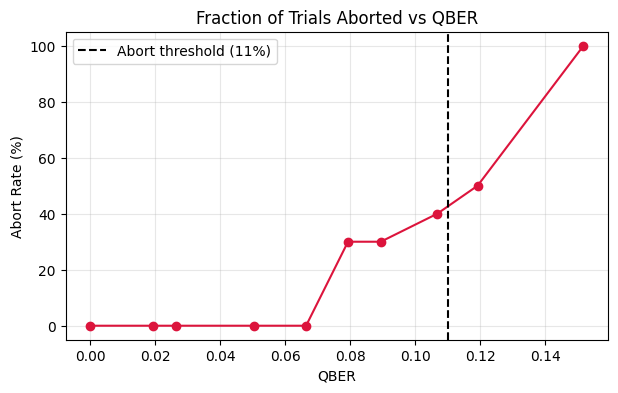

In [72]:
plt.plot(qber_vs_p_sorted, abort_rate_vs_p_sorted * 100, marker='o', color='crimson')
plt.axvline(0.11, color='black', linestyle='--', label="Abort threshold (11%)")
plt.xlabel("QBER")
plt.ylabel("Abort Rate (%)")
plt.title("Fraction of Trials Aborted vs QBER")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Final mismatches after reconciliation: 0
Reconciliation successful: True
Reconciled key length: 306
Total information leaked to Eve: 147 bits


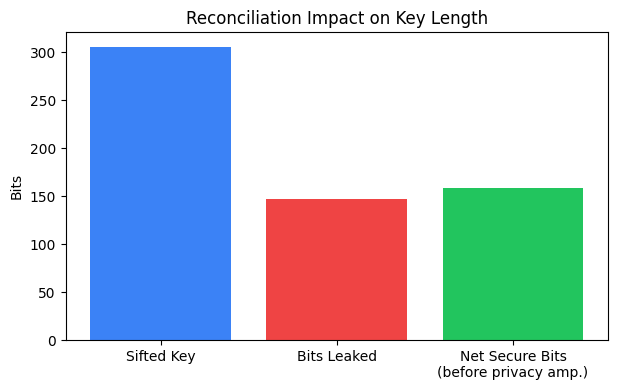

In [73]:
final_mismatches = np.sum(alice_sifted_rec != bob_reconciled)
print(f"Final mismatches after reconciliation: {final_mismatches}")
print(f"Reconciliation successful: {final_mismatches == 0}")
print(f"Reconciled key length: {len(bob_reconciled)}")
print(f"Total information leaked to Eve: {total_leaked_bits} bits")

# ### Visualization — Sifted vs Reconciled key length & leakage summary

# %%
plt.bar(["Sifted Key", "Bits Leaked", "Net Secure Bits\n(before privacy amp.)"],
        [len(alice_sifted_rec), total_leaked_bits, len(alice_sifted_rec) - total_leaked_bits],
        color=["#3b82f6", "#ef4444", "#22c55e"])
plt.ylabel("Bits")
plt.title("Reconciliation Impact on Key Length")
plt.show()

In [ ]:
# %%


def security_margin_bits(epsilon_pa=1e-6, epsilon_ec=1e-6):
    """
    Security margin derived from the Leftover Hash Lemma (Tomamichel et al.
    2011; Renner 2005), rather than an arbitrary constant.
    """
    pa_cost = 2 * np.log2(1 / epsilon_pa)
    ec_verification_cost = np.log2(1 / epsilon_ec)
    return pa_cost + ec_verification_cost


def compute_final_key_length(n_reconciled, leak_EC, qber, epsilon_pa=1e-6, epsilon_ec=1e-6):
    eve_info_bound = n_reconciled * binary_entropy(qber)
    margin = security_margin_bits(epsilon_pa, epsilon_ec)
    final_length = n_reconciled - leak_EC - eve_info_bound - margin
    return max(0, int(np.floor(final_length))), margin

In [75]:
def generate_toeplitz_matrix(n_out, n_in, seed=None):
    rng_local = np.random.default_rng(seed)
    first_col_and_row = rng_local.integers(0, 2, n_out + n_in - 1)
    toeplitz = np.zeros((n_out, n_in), dtype=int)
    for i in range(n_out):
        toeplitz[i, :] = first_col_and_row[i: i + n_in][::-1]
    return toeplitz


def toeplitz_hash(key_bits, n_out, seed=None):
    n_in = len(key_bits)
    if n_out <= 0:
        return np.array([], dtype=int)
    T = generate_toeplitz_matrix(n_out, n_in, seed=seed)
    final_key = (T @ key_bits) % 2
    return final_key

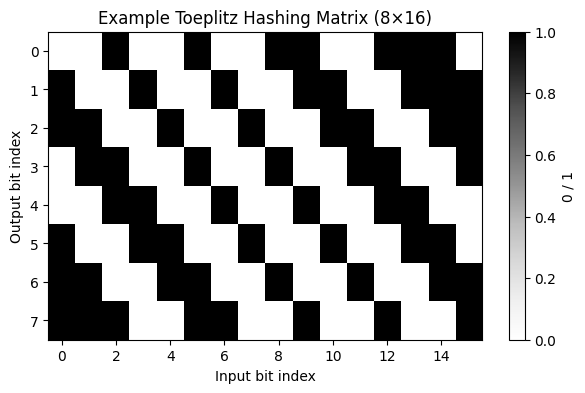

In [76]:
example_T = generate_toeplitz_matrix(n_out=8, n_in=16, seed=1)
plt.imshow(example_T, cmap="Greys", aspect="auto")
plt.title("Example Toeplitz Hashing Matrix (8×16)")
plt.xlabel("Input bit index")
plt.ylabel("Output bit index")
plt.colorbar(label="0 / 1")
plt.show()

In [77]:
# %%
DEMO_P = 0.2
alice_demo, bob_demo, *_ = run_bb84_with_eve(600, p_intercept=DEMO_P, seed=101)
observed_qber = np.mean(alice_demo != bob_demo)

bob_rec_demo, leak_demo, hist_demo, success_demo = attempt_reconciliation(
    alice_demo, bob_demo, max_passes=12, initial_block_size=8, seed=42
)

if success_demo:
    n_reconciled = len(alice_demo)
    final_len, margin_used = compute_final_key_length(
        n_reconciled, leak_demo, observed_qber, epsilon_pa=1e-6, epsilon_ec=1e-6
    )
    final_key = toeplitz_hash(alice_demo, final_len, seed=2024)
    final_key_bob = toeplitz_hash(bob_rec_demo, final_len, seed=2024)

    print(f"Observed QBER: {observed_qber:.2%}")
    print(f"Sifted/reconciled key length: {n_reconciled}")
    print(f"Bits leaked during reconciliation: {leak_demo}")
    print(f"Estimated Eve info bound (entropy): {n_reconciled * binary_entropy(observed_qber):.1f} bits")
    print(f"Security margin (epsilon_pa=1e-6, epsilon_ec=1e-6): {margin_used:.1f} bits")
    print(f"Final secure key length: {final_len}")
    print(f"Alice's final key: {final_key}")
    print(f"Bob's final key:   {final_key_bob}")
    print(f"Keys match: {np.array_equal(final_key, final_key_bob)}")
else:
    print("Reconciliation failed or QBER exceeded abort threshold — no final key generated.")

Observed QBER: 4.10%
Sifted/reconciled key length: 317
Bits leaked during reconciliation: 103
Estimated Eve info bound (entropy): 78.3 bits
Security margin (epsilon_pa=1e-6, epsilon_ec=1e-6): 59.8 bits
Final secure key length: 75
Alice's final key: [1 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 1 1
 1 0 1 0 0 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0
 0]
Bob's final key:   [1 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 1 1
 1 0 1 0 0 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0
 0]
Keys match: True


In [78]:
# Tightening epsilon (stronger security guarantee) increases the security
# margin, shrinking the final key. This makes explicit the trade-off that
# was hidden by the flat constant previously used.

# %%
epsilon_values = [1e-3, 1e-6, 1e-9, 1e-12]
demo_n_reconciled, demo_leak, demo_qber = n_reconciled, leak_demo, observed_qber

print(f"{'epsilon':>10} | {'margin (bits)':>15} | {'final key length':>18}")
for eps in epsilon_values:
    margin = security_margin_bits(epsilon_pa=eps, epsilon_ec=eps)
    length, _ = compute_final_key_length(demo_n_reconciled, demo_leak, demo_qber, epsilon_pa=eps, epsilon_ec=eps)
    print(f"{eps:>10.0e} | {margin:>15.1f} | {length:>18d}")

   epsilon |   margin (bits) |   final key length
     1e-03 |            29.9 |                105
     1e-06 |            59.8 |                 75
     1e-09 |            89.7 |                 46
     1e-12 |           119.6 |                 16


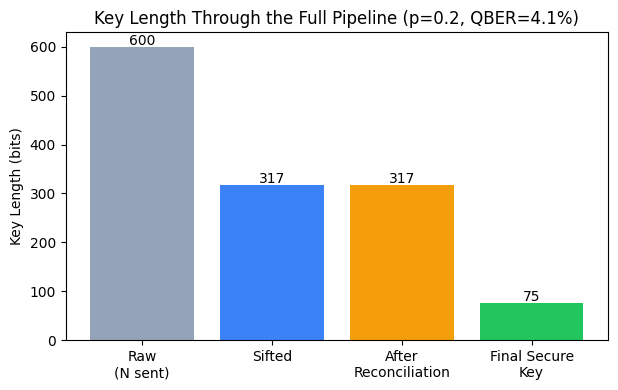

In [79]:
stages = ["Raw\n(N sent)", "Sifted", "After\nReconciliation", "Final Secure\nKey"]
lengths = [600, n_reconciled, n_reconciled, final_len]

plt.bar(stages, lengths, color=["#94a3b8", "#3b82f6", "#f59e0b", "#22c55e"])
plt.ylabel("Key Length (bits)")
plt.title(f"Key Length Through the Full Pipeline (p={DEMO_P}, QBER={observed_qber:.1%})")
for i, v in enumerate(lengths):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

In [80]:
def full_pipeline_key_rate(n_raw, p_intercept, seed=0, epsilon_pa=1e-6, epsilon_ec=1e-6):
    a, b, *_ = run_bb84_with_eve(n_raw, p_intercept=p_intercept, seed=seed)
    if len(a) == 0:
        return 0.0, 0.0

    qber = np.mean(a != b)
    b_rec, leak, _, success = attempt_reconciliation(a, b, max_passes=14, initial_block_size=8, seed=seed + 500)

    if not success or b_rec is None:
        return qber, 0.0

    final_len, _ = compute_final_key_length(len(a), leak, qber, epsilon_pa=epsilon_pa, epsilon_ec=epsilon_ec)
    key_rate = final_len / n_raw
    return qber, key_rate

# %%
p_values_kr = np.linspace(0, 0.6, 13)
trials_per_p = 6
n_raw = 600

qber_kr_avg, keyrate_kr_avg = [], []

for p in p_values_kr:
    qbers, rates = [], []
    for t in range(trials_per_p):
        q, r = full_pipeline_key_rate(n_raw, p, seed=int(p * 10000) + t)
        qbers.append(q)
        rates.append(r)
    qber_kr_avg.append(np.mean(qbers))
    keyrate_kr_avg.append(np.mean(rates))

sort_idx = np.argsort(qber_kr_avg)
qber_kr_sorted = np.array(qber_kr_avg)[sort_idx]
keyrate_kr_sorted = np.array(keyrate_kr_avg)[sort_idx]

ABORT: QBER 11.11% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.36% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.67% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.46% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.04% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.69% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.97% exceeds threshold 11%. Discarding key.
ABORT: QBER 14.69% exceeds threshold 11%. Discarding key.
ABORT: QBER 15.41% exceeds threshold 11%. Discarding key.
ABORT: QBER 12.62% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.19% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.75% exceeds threshold 11%. Discarding key.
ABORT: QBER 15.70% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.22% exceeds threshold 11%. Discarding key.
ABORT: QBER 17.16% exceeds threshold 11%. Discarding key.
ABORT: QBER 15.86% exceeds threshold 11%. Discarding key.
ABORT: QBER 17.25% exceeds threshold 11%. Discarding key.
ABORT: QBER 11

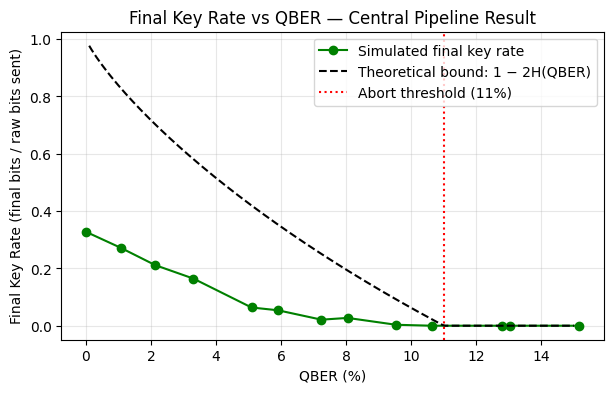

In [81]:
qber_theory_range = np.linspace(0.001, 0.15, 200)
theory_rate = 1 - 2 * binary_entropy(qber_theory_range)
theory_rate = np.clip(theory_rate, 0, None)

plt.plot(qber_kr_sorted * 100, keyrate_kr_sorted, marker='o', color='green', label="Simulated final key rate")
plt.plot(qber_theory_range * 100, theory_rate, linestyle='--', color='black', label="Theoretical bound: 1 − 2H(QBER)")
plt.axvline(11, color='red', linestyle=':', label="Abort threshold (11%)")
plt.xlabel("QBER (%)")
plt.ylabel("Final Key Rate (final bits / raw bits sent)")
plt.title("Final Key Rate vs QBER — Central Pipeline Result")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

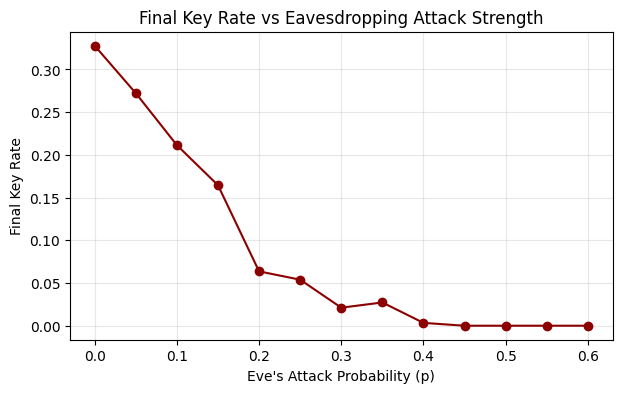

Final key rate summary:
  p=0.00 -> QBER=0.00% -> key rate=0.328  [OK]
  p=0.05 -> QBER=1.06% -> key rate=0.272  [OK]
  p=0.10 -> QBER=2.13% -> key rate=0.211  [OK]
  p=0.15 -> QBER=3.30% -> key rate=0.164  [OK]
  p=0.20 -> QBER=5.09% -> key rate=0.064  [OK]
  p=0.25 -> QBER=5.90% -> key rate=0.054  [OK]
  p=0.30 -> QBER=7.24% -> key rate=0.021  [OK]
  p=0.35 -> QBER=8.04% -> key rate=0.027  [OK]
  p=0.40 -> QBER=9.53% -> key rate=0.003  [OK]
  p=0.45 -> QBER=10.63% -> key rate=0.000  [OK]
  p=0.50 -> QBER=13.04% -> key rate=0.000  [ABORT ZONE]
  p=0.55 -> QBER=15.16% -> key rate=0.000  [ABORT ZONE]
  p=0.60 -> QBER=12.78% -> key rate=0.000  [ABORT ZONE]


In [82]:
plt.plot(p_values_kr, keyrate_kr_avg, marker='o', color='darkred')
plt.xlabel("Eve's Attack Probability (p)")
plt.ylabel("Final Key Rate")
plt.title("Final Key Rate vs Eavesdropping Attack Strength")
plt.grid(alpha=0.3)
plt.show()

print("Final key rate summary:")
for p, q, r in zip(p_values_kr, qber_kr_avg, keyrate_kr_avg):
    status = "ABORT ZONE" if q > 0.11 else "OK"
    print(f"  p={p:.2f} -> QBER={q:.2%} -> key rate={r:.3f}  [{status}]")

ABORT: QBER 14.66% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.33% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.15% exceeds threshold 11%. Discarding key.
ABORT: QBER 14.79% exceeds threshold 11%. Discarding key.
ABORT: QBER 14.05% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.77% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.71% exceeds threshold 11%. Discarding key.
ABORT: QBER 16.72% exceeds threshold 11%. Discarding key.
ABORT: QBER 11.33% exceeds threshold 11%. Discarding key.
ABORT: QBER 20.19% exceeds threshold 11%. Discarding key.
ABORT: QBER 12.96% exceeds threshold 11%. Discarding key.
ABORT: QBER 17.22% exceeds threshold 11%. Discarding key.
ABORT: QBER 12.29% exceeds threshold 11%. Discarding key.
ABORT: QBER 13.04% exceeds threshold 11%. Discarding key.


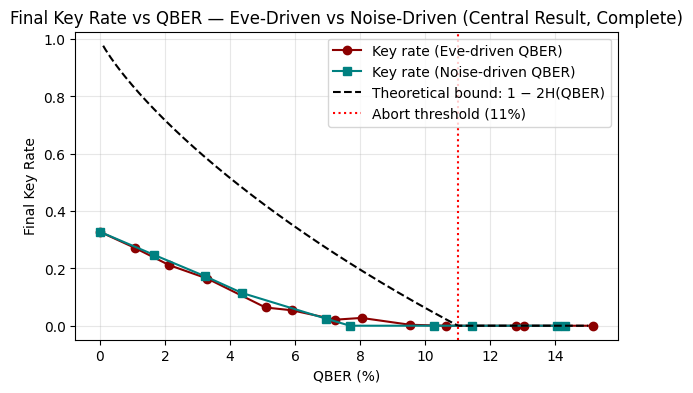

Final key rate summary — pure channel noise (no Eve):
  noise_q=0.00 -> QBER=0.00% -> key rate=0.328  [OK]
  noise_q=0.02 -> QBER=1.65% -> key rate=0.248  [OK]
  noise_q=0.03 -> QBER=3.22% -> key rate=0.173  [OK]
  noise_q=0.05 -> QBER=4.37% -> key rate=0.114  [OK]
  noise_q=0.07 -> QBER=6.94% -> key rate=0.025  [OK]
  noise_q=0.08 -> QBER=7.69% -> key rate=0.000  [OK]
  noise_q=0.10 -> QBER=10.26% -> key rate=0.000  [OK]
  noise_q=0.12 -> QBER=11.44% -> key rate=0.000  [ABORT ZONE]
  noise_q=0.13 -> QBER=14.06% -> key rate=0.000  [ABORT ZONE]
  noise_q=0.15 -> QBER=14.28% -> key rate=0.000  [ABORT ZONE]


In [83]:
def full_pipeline_key_rate_noise(n_raw, depolarizing_q=0.0, seed=0, epsilon_pa=1e-6, epsilon_ec=1e-6):
    """
    Same as full_pipeline_key_rate, but sweeps pure channel noise
    (no Eve) instead of attack strength.
    """
    rng_local = np.random.default_rng(seed)
    a, b, *_ = run_bb84_with_eve(n_raw, p_intercept=0.0, seed=seed)  # no Eve
    if len(a) == 0:
        return 0.0, 0.0

    b_noisy = apply_depolarizing_noise(b, depolarizing_q, rng_local)
    qber = np.mean(a != b_noisy)

    b_rec, leak, _, success = attempt_reconciliation(a, b_noisy, max_passes=14, initial_block_size=8, seed=seed + 500)

    if not success or b_rec is None:
        return qber, 0.0

    final_len, _ = compute_final_key_length(len(a), leak, qber, epsilon_pa=epsilon_pa, epsilon_ec=epsilon_ec)
    key_rate = final_len / n_raw
    return qber, key_rate

# %%
q_values_kr = np.linspace(0, 0.15, 10)
trials_per_q = 6
n_raw_noise = 600

qber_noise_kr, keyrate_noise_kr = [], []

for q in q_values_kr:
    qbers, rates = [], []
    for t in range(trials_per_q):
        qq, r = full_pipeline_key_rate_noise(n_raw_noise, depolarizing_q=q, seed=int(q * 10000) + t)
        qbers.append(qq)
        rates.append(r)
    qber_noise_kr.append(np.mean(qbers))
    keyrate_noise_kr.append(np.mean(rates))

sort_idx_noise = np.argsort(qber_noise_kr)
qber_noise_kr_sorted = np.array(qber_noise_kr)[sort_idx_noise]
keyrate_noise_kr_sorted = np.array(keyrate_noise_kr)[sort_idx_noise]

# %%
plt.plot(qber_kr_sorted * 100, keyrate_kr_sorted, marker='o', color='darkred', label="Key rate (Eve-driven QBER)")
plt.plot(qber_noise_kr_sorted * 100, keyrate_noise_kr_sorted, marker='s', color='teal', label="Key rate (Noise-driven QBER)")
plt.plot(qber_theory_range * 100, theory_rate, linestyle='--', color='black', label="Theoretical bound: 1 − 2H(QBER)")
plt.axvline(11, color='red', linestyle=':', label="Abort threshold (11%)")
plt.xlabel("QBER (%)")
plt.ylabel("Final Key Rate")
plt.title("Final Key Rate vs QBER — Eve-Driven vs Noise-Driven (Central Result, Complete)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final key rate summary — pure channel noise (no Eve):")
for q_lvl, qq, r in zip(q_values_kr, qber_noise_kr, keyrate_noise_kr):
    status = "ABORT ZONE" if qq > 0.11 else "OK"
    print(f"  noise_q={q_lvl:.2f} -> QBER={qq:.2%} -> key rate={r:.3f}  [{status}]")

In [84]:
sample_sizes = [50, 200, 1000]
p_fixed = 0.3
n_repeats = 30

for n in sample_sizes:
    qbers = []
    for t in range(n_repeats):
        a, b, *_ = run_bb84_with_eve(n, p_intercept=p_fixed, seed=t + n)
        if len(a) > 0:
            qbers.append(np.mean(a != b))
    print(f"N={n:5d} -> mean QBER={np.mean(qbers):.2%}, std dev={np.std(qbers):.2%}")

N=   50 -> mean QBER=7.64%, std dev=5.03%
N=  200 -> mean QBER=6.49%, std dev=2.47%
N= 1000 -> mean QBER=7.37%, std dev=1.21%
